# Аналитика и визуализация начислений ЖКУ (ЕПД МосОблЕИРЦ)

Данный ноутбук содержит примеры аналитических SQL-запросов к оцифрованным квитанциям из базы данных SQLite `db/receipts.db` и построение графиков:
- 📊 Динамика общей суммы платежей по месяцам
- 🥧 Структура расходов по категориям (жилищные, коммунальные, иные услуги)
- 🌡️ Анализ сезонного потребления отопления (Гкал и рубли)
- ⚡ Динамика потребления ресурсов (электроэнергия, водоотведение)
- 🏆 Рейтинг самых затратных услуг
- 🔍 Сведения о перерасчетах


In [15]:
import sqlite3
from pathlib import Path

# Проверяем наличие библиотек pandas и matplotlib
try:
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
    plt.rcParams["figure.figsize"] = (10, 5)
    plt.rcParams["font.size"] = 10
    HAS_PLOT_LIBS = True
except ImportError:
    HAS_PLOT_LIBS = False
    print("Для отображения графиков установите pandas и matplotlib: pip install pandas matplotlib")

# Путь к базе данных receipts.db
DB_PATH = Path("..") / "db" / "receipts.db"
conn = sqlite3.connect(str(DB_PATH))
conn.row_factory = sqlite3.Row
print(f"Подключено к базе данных: {DB_PATH.resolve()}")

Подключено к базе данных: D:\PyProjects\_my\pdf_table_parcer\db\receipts.db


---
## 1. Лицевой счет и реестр загруженных квитанций

In [16]:
cursor = conn.cursor()
account = cursor.execute("SELECT * FROM accounts LIMIT 1").fetchone()
if account:
    print(f"Лицевой счет: {account['account_number']}")
    print(f"Плательщик:   {account['payer_name']}")
    print(f"Адрес:        {account['address']}\n")

# Список загруженных квитанций
if HAS_PLOT_LIBS:
    df_receipts = pd.read_sql_query(
        "SELECT id, period, period_date, total_to_pay, source_file FROM receipts ORDER BY period_date;",
        conn
    )
    display(df_receipts)
else:
    rows = cursor.execute("SELECT id, period, period_date, total_to_pay FROM receipts ORDER BY period_date;").fetchall()
    for r in rows:
        print(dict(r))

Лицевой счет: 32546-580
Плательщик:   БЕГМА МАКСИМ ВАЛЕНТИНОВИЧ
Адрес:        141102, МОСКОВСКАЯ ОБЛ., Г.О. ЩЁЛКОВО, Г ЩЁЛКОВО, УЛ ШМИДТА, д.1, кв.244



,id,period,period_date,total_to_pay,source_file
0,1,январь 2026,2026-01-01,19558.66,Шмидта-1-01 2026.pdf
1,2,февраль 2026,2026-02-01,20584.76,Шмидта-1-02 2026.pdf
2,3,март 2026,2026-03-01,19493.98,Шмидта-1-03 2026.pdf
3,4,апрель 2026,2026-04-01,17536.48,Шмидта-1-04 2026.pdf
4,5,май 2026,2026-05-01,14781.24,Шмидта-1-05 2026.pdf
5,6,июнь 2026,2026-06-01,12409.63,Шмидта-1-06 2026.pdf
6,7,июль 2026,2026-07-01,10064.11,Шмидта-1-07 2026.pdf
7,8,август 2026,2026-08-01,11073.13,Шмидта-1-08 2026.pdf
8,9,сентябрь 2026,2026-09-01,10914.53,Шмидта-1-09 2026.pdf


---
## 2. Динамика общей суммы начислений по месяцам
График общей суммы к оплате (без учета добровольного страхования) с января по сентябрь 2026 года.

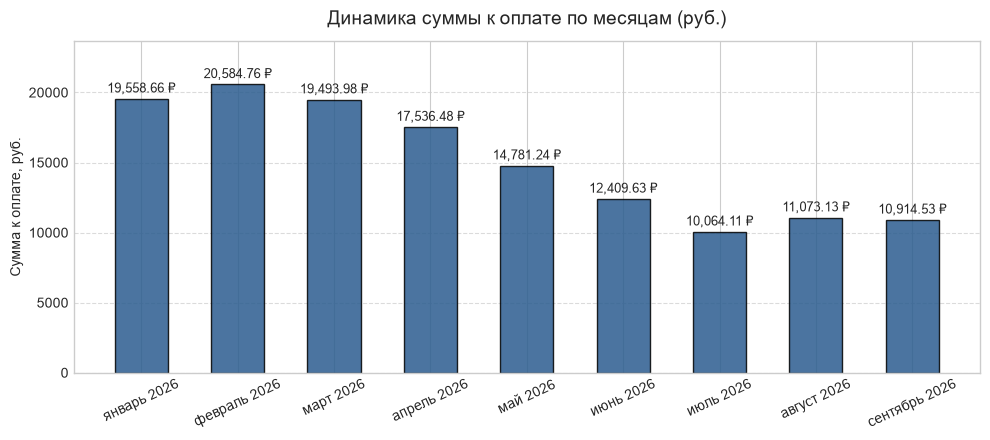

In [17]:
query_totals = """
    SELECT period_date, period, total_to_pay
    FROM receipts
    ORDER BY period_date;
"""

if HAS_PLOT_LIBS:
    df_totals = pd.read_sql_query(query_totals, conn)
    
    fig, ax = plt.subplots(figsize=(10, 4.5))
    bars = ax.bar(df_totals["period"], df_totals["total_to_pay"], color="#2b5c8f", width=0.55, edgecolor="black", alpha=0.85)
    
    ax.set_title("Динамика суммы к оплате по месяцам (руб.)", fontsize=14, pad=12)
    ax.set_ylabel("Сумма к оплате, руб.")
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, yval + 250, f"{yval:,.2f} ₽", ha="center", va="bottom", fontsize=9)
    
    ax.set_ylim(0, df_totals["total_to_pay"].max() * 1.15)
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()
else:
    for r in conn.execute(query_totals):
        print(f"{r['period']}: {r['total_to_pay']} руб.")

---
## 3. Распределение начислений по категориям услуг
Сравнение долей жилищных, коммунальных и иных услуг в общей сумме начислений.

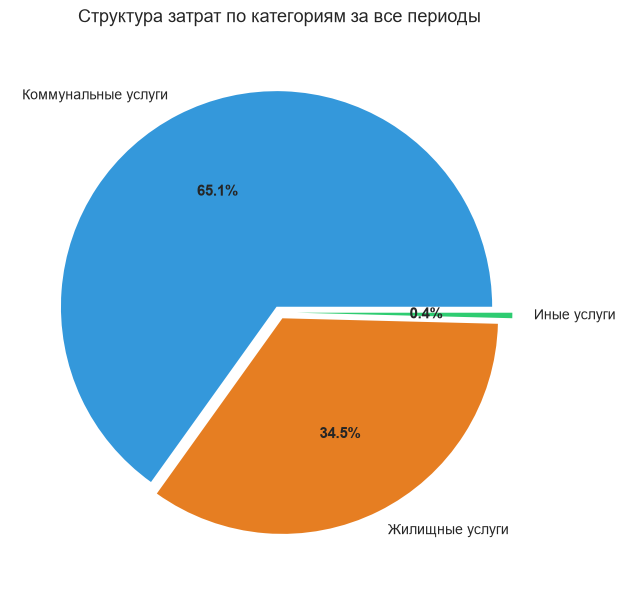

In [25]:
query_categories = """
    SELECT service_category, ROUND(SUM(total_amount), 2) AS category_sum
    FROM service_charges
    GROUP BY service_category
    ORDER BY category_sum DESC;
"""

if HAS_PLOT_LIBS:
    df_cats = pd.read_sql_query(query_categories, conn)
    
    fig, ax = plt.subplots(figsize=(7, 7))
    colors = ["#3498db", "#e67e22", "#2ecc71"]
    wedges, texts, autotexts = ax.pie(
        df_cats["category_sum"],
        labels=df_cats["service_category"],
        autopct="%1.1f%%",
        startangle=0,
        colors=colors,
        explode=[0.03, 0.03, 0.08],
        shadow=False
    )
    for at in autotexts:
        at.set_fontsize(11)
        at.set_weight("bold")
        
    ax.set_title("Структура затрат по категориям за все периоды", fontsize=13, pad=15)
    plt.show()
else:
    for r in conn.execute(query_categories):
        print(dict(r))

---
## 4. Сезонный анализ отопления
Динамика расхода (Гкал) и суммы начислений за отопление по месяцам (демонстрирует окончание отопительного периода весной).

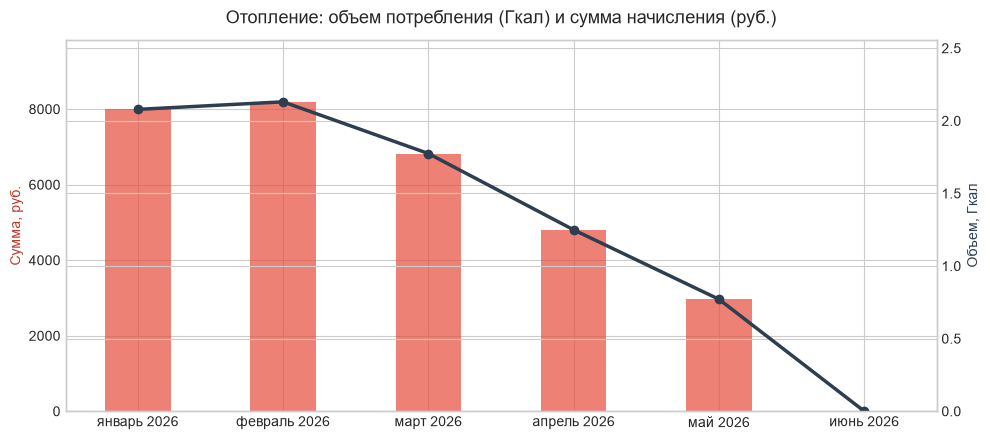

In [19]:
query_heating = """
    SELECT r.period, r.period_date, sc.volume, sc.tariff, sc.total_amount
    FROM service_charges sc
    JOIN receipts r ON sc.receipt_id = r.id
    WHERE sc.service_name LIKE '%ОТОПЛЕНИЕ%'
    ORDER BY r.period_date;
"""

if HAS_PLOT_LIBS:
    df_heating = pd.read_sql_query(query_heating, conn)
    
    fig, ax1 = plt.subplots(figsize=(10, 4.5))
    ax2 = ax1.twinx()
    
    bars = ax1.bar(df_heating["period"], df_heating["total_amount"], color="#e74c3c", alpha=0.7, width=0.45, label="Сумма, руб.")
    line = ax2.plot(df_heating["period"], df_heating["volume"], color="#2c3e50", marker="o", linewidth=2.5, label="Объем, Гкал")
    
    ax1.set_title("Отопление: объем потребления (Гкал) и сумма начисления (руб.)", fontsize=13, pad=12)
    ax1.set_ylabel("Сумма, руб.", color="#c0392b")
    ax2.set_ylabel("Объем, Гкал", color="#2c3e50")
    ax1.set_ylim(0, df_heating["total_amount"].max() * 1.2)
    ax2.set_ylim(0, df_heating["volume"].max() * 1.2)
    
    plt.xticks(rotation=25)
    fig.tight_layout()
    plt.show()
else:
    for r in conn.execute(query_heating):
        print(dict(r))

---
## 5. Динамика расхода электроэнергии и водоотведения
Отслеживание объемов потребления ресурсов в физических величинах (кВт*ч и куб.м).

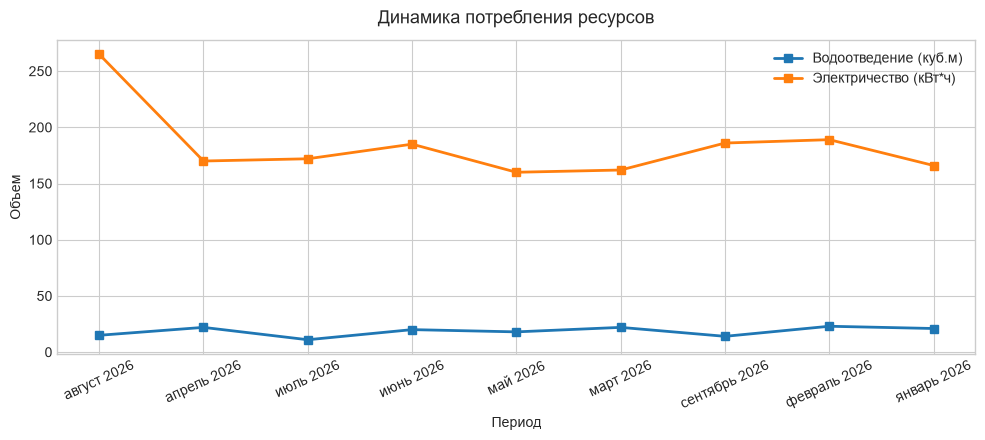

In [20]:
query_resources = """
    SELECT r.period, sc.service_name, sc.volume, sc.unit
    FROM service_charges sc
    JOIN receipts r ON sc.receipt_id = r.id
    WHERE sc.service_name LIKE '%ЭЛЕКТРИЧЕСТВО%' OR sc.service_name = 'ВОДООТВЕДЕНИЕ'
    ORDER BY r.period_date;
"""

if HAS_PLOT_LIBS:
    df_res = pd.read_sql_query(query_resources, conn)
    pivot_res = df_res.pivot(index="period", columns="service_name", values="volume")
    
    pivot_res.plot(kind="line", marker="s", linewidth=2, figsize=(10, 4.5))
    plt.title("Динамика потребления ресурсов", fontsize=13, pad=12)
    plt.ylabel("Объем")
    plt.xlabel("Период")
    plt.legend(["Водоотведение (куб.м)", "Электричество (кВт*ч)"])
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()
else:
    for r in conn.execute(query_resources):
        print(dict(r))

---
## 6. Топ-10 самых затратных услуг за весь период

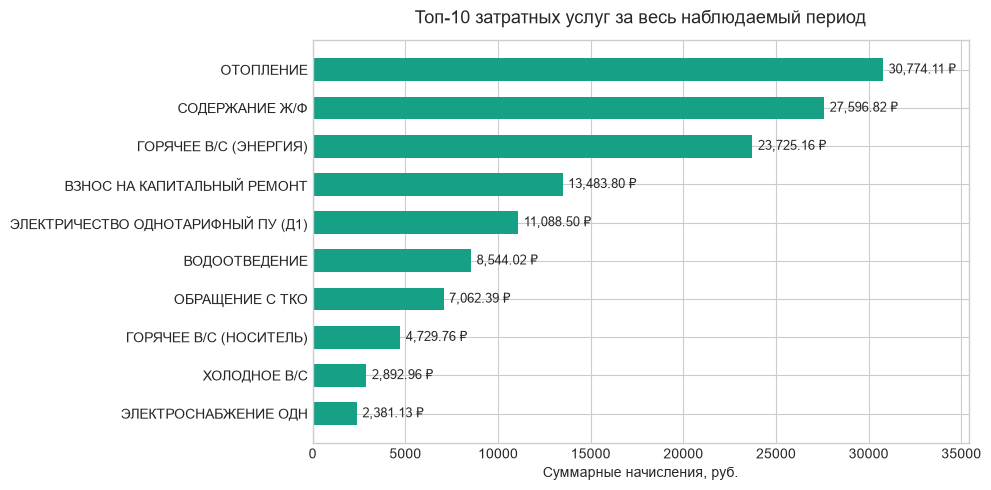

In [21]:
query_top = """
    SELECT service_name, ROUND(SUM(total_amount), 2) AS total_sum
    FROM service_charges
    GROUP BY service_name
    ORDER BY total_sum DESC
    LIMIT 10;
"""

if HAS_PLOT_LIBS:
    df_top = pd.read_sql_query(query_top, conn)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(df_top["service_name"][::-1], df_top["total_sum"][::-1], color="#16a085", height=0.6)
    
    ax.set_title("Топ-10 затратных услуг за весь наблюдаемый период", fontsize=13, pad=12)
    ax.set_xlabel("Суммарные начисления, руб.")
    
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 300, bar.get_y() + bar.get_height() / 2, f"{w:,.2f} ₽", va="center", fontsize=9)
        
    ax.set_xlim(0, df_top["total_sum"].max() * 1.15)
    plt.tight_layout()
    plt.show()
else:
    for r in conn.execute(query_top):
        print(f"{r['service_name']}: {r['total_sum']} руб.")

---
## 7. Сведения о перерасчетах
Выборка всех услуг, по которым производились перерасчеты (`recalculation != 0`).

In [22]:
query_recalc = """
    SELECT r.period, sc.service_name, sc.recalculation, sc.total_amount
    FROM service_charges sc
    JOIN receipts r ON sc.receipt_id = r.id
    WHERE ABS(sc.recalculation) > 0.01
    ORDER BY r.period_date, sc.service_name;
"""

if HAS_PLOT_LIBS:
    df_recalc = pd.read_sql_query(query_recalc, conn)
    if not df_recalc.empty:
        display(df_recalc)
    else:
        print("Перерасчетов за данный период не обнаружено.")
else:
    rows = conn.execute(query_recalc).fetchall()
    for r in rows:
        print(dict(r))

,period,service_name,recalculation,total_amount
0,март 2026,ВОДООТВЕДЕНИЕ ОДН,239.89,245.72
1,март 2026,ХОЛОДНОЕ В/С ОДН,239.60,242.20
2,март 2026,ЭЛЕКТРОСНАБЖЕНИЕ ОДН,77.31,281.75
3,апрель 2026,ВОДООТВЕДЕНИЕ ОДН,239.89,245.72
4,апрель 2026,ХОЛОДНОЕ В/С ОДН,239.60,242.20
5,апрель 2026,ЭЛЕКТРОСНАБЖЕНИЕ ОДН,77.31,281.75
6,май 2026,ВОДООТВЕДЕНИЕ ОДН,239.89,245.72
7,май 2026,ХОЛОДНОЕ В/С ОДН,239.60,242.20
8,май 2026,ЭЛЕКТРОСНАБЖЕНИЕ ОДН,77.31,281.75
9,июнь 2026,ВОДООТВЕДЕНИЕ ОДН,239.89,245.72
